# ClimateTwin — Complete Solution Notebook

**Instructor solution for AquaAir General Insurance**

This notebook solves the core case exactly as framed in the student materials:

**Observe → Model → Price → Stress → Mitigate → Reprice**

The analysis deliberately remains within the minimum viable classroom scope. It uses:
- exposure-adjusted Poisson frequency;
- Gamma-log conditional severity;
- frequency × severity expected loss;
- transparent indicated premium;
- Monte Carlo aggregate annual loss;
- VaR99 and TVaR99;
- four core climate scenarios; and
- a budget-constrained mitigation decision.

Advanced spatial models, copulas, credibility, reinsurance and adaptive optimization are not required.


In [1]:
# Core imports and reproducibility
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

SEED = 20260908
rng = np.random.default_rng(SEED)

DATA_PATH = Path("dataset.csv")
FIXED_EXPENSE = 750
VARIABLE_EXPENSE_RATIO = 0.25
PROFIT_CONTINGENCY = 0.05
RESILIENCE_BUDGET = 8_000_000

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-joecz7dr because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
# Load the exact teaching dataset
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Years:", sorted(df["year"].unique()))
print("Locations:", df["location_id"].nunique())
print("Claims:", int(df["claim_count"].sum()))
display(df.head())


Shape: (750, 35)
Years: [np.int64(2024), np.int64(2025), np.int64(2026)]
Locations: 250
Claims: 138


,policy_id,location_id,year,region,occupancy,exposure_years,insured_value,policy_limit,deductible,bi_waiting_period_days,current_premium,pm25,ozone,turbidity,water_quality_index,temperature_c,annual_rainfall_mm,drought_indicator,air_stress_flag,water_stress_flag,air_trigger_flag,water_trigger_flag,compound_trigger_flag,insured_trigger_type,bi_waiting_period_met_flag,air_filtration,water_treatment,business_continuity_plan,air_filtration_upgrade_cost,water_treatment_upgrade_cost,bcp_upgrade_cost,claim_count,aggregate_ground_up_loss,aggregate_covered_loss,aggregate_paid_loss
0,POL001-2024,LOC001,2024,Drylands,Hospital,0.726,30810000,10780000,75000,2,83300,30.900,61.600,1.850,54.900,28.300,451.900,0.588,0,1,0,0,0,NaN,0,0,0,0,109000,147000,60000,0,0.000,0.000,0.000
1,POL001-2025,LOC001,2025,Drylands,Hospital,0.702,32530000,11390000,50000,1,84600,40.100,66.800,4.390,64.700,33.600,418.000,0.838,1,0,0,0,0,NaN,0,0,0,0,109000,147000,60000,0,0.000,0.000,0.000
2,POL001-2026,LOC001,2026,Drylands,Hospital,0.731,32220000,16110000,100000,2,82100,37.300,82.700,6.650,54.900,32.200,467.300,0.642,1,1,0,0,0,NaN,0,0,0,0,109000,147000,60000,0,0.000,0.000,0.000
3,POL002-2024,LOC002,2024,Central Metro,Manufacturing,0.738,12070000,6040000,60000,2,27300,41.300,80.800,1.320,68.900,28.600,784.400,0.257,1,0,0,0,0,NaN,0,1,0,0,0,96000,45000,0,0.000,0.000,0.000
4,POL002-2025,LOC002,2025,Central Metro,Manufacturing,0.997,12140000,6070000,40000,1,35500,46.700,77.700,3.960,67.900,32.200,778.400,0.340,1,0,1,0,0,Air,1,1,0,0,0,96000,45000,1,"101,868.090","101,868.090","61,868.090"


In [3]:
# Helper feature engineering used throughout the case
def add_model_features(data):
    x = data.copy()
    x["pm25_10"] = x["pm25"] / 10.0
    x["ozone_10"] = x["ozone"] / 10.0
    x["turbidity_2"] = x["turbidity"] / 2.0
    x["wqi_10"] = x["water_quality_index"] / 10.0
    x["temp_5"] = x["temperature_c"] / 5.0
    x["rain_500"] = x["annual_rainfall_mm"] / 500.0
    x["log_iv"] = np.log(x["insured_value"])
    x["air_water_interaction"] = x["air_stress_flag"] * x["water_stress_flag"]
    return x

def apply_scenario(data, scenario):
    x = data.copy()

    if scenario in ("Air stress", "Compound stress"):
        x["pm25"] = x["pm25"] + 15.0
        x["ozone"] = x["ozone"] + 10.0

    if scenario in ("Water stress", "Compound stress"):
        x["turbidity"] = x["turbidity"] * 1.60
        x["water_quality_index"] = (x["water_quality_index"] - 15.0).clip(lower=0)

    x["air_stress_flag"] = ((x["pm25"] >= 35.0) | (x["ozone"] >= 70.0)).astype(int)
    x["water_stress_flag"] = ((x["turbidity"] >= 5.0) | (x["water_quality_index"] <= 60.0)).astype(int)

    return add_model_features(x)

dfm = add_model_features(df)
portfolio_2026 = dfm.loc[dfm["year"] == 2026].copy().reset_index(drop=True)


## Stage 1 — Observe: portfolio, coverage and baseline experience

In [4]:
# Core validation and descriptive summaries
summary = pd.Series({
    "rows": len(df),
    "unique_locations": df["location_id"].nunique(),
    "years": df["year"].nunique(),
    "total_exposure": df["exposure_years"].sum(),
    "total_claims": df["claim_count"].sum(),
    "total_paid_loss": df["aggregate_paid_loss"].sum(),
    "air_stress_rows": df["air_stress_flag"].sum(),
    "air_trigger_rows": df["air_trigger_flag"].sum(),
    "water_stress_rows": df["water_stress_flag"].sum(),
    "water_trigger_rows": df["water_trigger_flag"].sum(),
    "compound_trigger_rows": df["compound_trigger_flag"].sum(),
})
display(summary.to_frame("value"))

assert len(df) == 750
assert df["location_id"].nunique() == 250
assert ((df["claim_count"] > 0) & (df["insured_trigger_type"] == "None")).sum() == 0

by_occ = (df.groupby("occupancy")
          .agg(exposure=("exposure_years","sum"),
               claims=("claim_count","sum"),
               paid_loss=("aggregate_paid_loss","sum"))
          .assign(claim_frequency=lambda x: x["claims"]/x["exposure"],
                  paid_severity=lambda x: x["paid_loss"]/x["claims"]))
display(by_occ)

by_region = (df.groupby("region")
             .agg(exposure=("exposure_years","sum"),
                  claims=("claim_count","sum"),
                  paid_loss=("aggregate_paid_loss","sum"))
             .assign(claim_frequency=lambda x: x["claims"]/x["exposure"],
                     paid_severity=lambda x: x["paid_loss"]/x["claims"]))
display(by_region)


,value
rows,750.000
unique_locations,250.000
years,3.000
total_exposure,646.671
total_claims,138.000
total_paid_loss,"22,583,153.260"
air_stress_rows,405.000
air_trigger_rows,150.000
water_stress_rows,327.000
water_trigger_rows,107.000


,exposure,claims,paid_loss,claim_frequency,paid_severity
occupancy,,,,,
Food Processing,193.472,45,"5,635,443.670",0.233,"125,232.082"
Hospital,156.782,35,"8,530,565.740",0.223,"243,730.450"
Manufacturing,296.417,58,"8,417,143.850",0.196,"145,123.170"


,exposure,claims,paid_loss,claim_frequency,paid_severity
region,,,,,
Central Metro,153.868,40,"4,343,974.920",0.260,"108,599.373"
Coastview,147.644,20,"4,091,448.860",0.135,"204,572.443"
Drylands,138.987,47,"9,102,158.030",0.338,"193,662.937"
Northgate,121.058,10,"1,348,643.160",0.083,"134,864.316"
Riverbend,85.114,21,"3,696,928.290",0.247,"176,044.204"


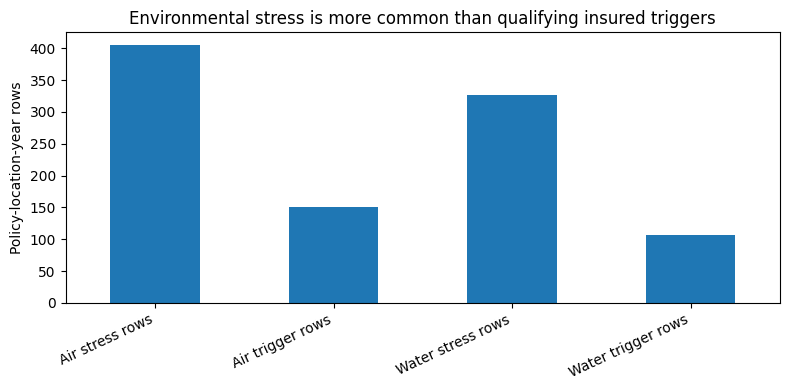

In [5]:
# Visualize environmental stress versus qualifying insured triggers.
stress_trigger = pd.DataFrame({
    "Air stress rows": [df["air_stress_flag"].sum()],
    "Air trigger rows": [df["air_trigger_flag"].sum()],
    "Water stress rows": [df["water_stress_flag"].sum()],
    "Water trigger rows": [df["water_trigger_flag"].sum()],
}).T
stress_trigger.columns = ["Count"]

ax = stress_trigger.plot(kind="bar", legend=False, figsize=(8,4))
ax.set_ylabel("Policy-location-year rows")
ax.set_title("Environmental stress is more common than qualifying insured triggers")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


**Instructor interpretation.** The key coverage lesson is visible immediately: many observations meet an environmental stress threshold, but fewer become qualifying insured triggers. Claims occur only when a qualifying trigger exists. Therefore, the actuarial response must model how hazard interacts with exposure, vulnerability, policy conditions and mitigation rather than treating pollution or contamination readings as losses themselves.

## Stage 2 — Exposure-adjusted claim frequency

In [6]:
freq_formula = (
    "claim_count ~ C(occupancy) + C(region) "
    "+ pm25_10 + ozone_10 + turbidity_2 + wqi_10 "
    "+ temp_5 + rain_500 + drought_indicator "
    "+ air_stress_flag + water_stress_flag + air_water_interaction "
    "+ air_filtration + water_treatment + business_continuity_plan"
)

freq_model = smf.glm(
    formula=freq_formula,
    data=dfm,
    family=sm.families.Poisson(),
    offset=np.log(dfm["exposure_years"])
).fit()

display(freq_model.summary())

rr = pd.DataFrame({
    "coefficient": freq_model.params,
    "rate_ratio": np.exp(freq_model.params),
    "p_value": freq_model.pvalues
}).sort_values("p_value")
display(rr.head(12))


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:            claim_count   No. Observations:                  750
Model:                            GLM   Df Residuals:                      730
Model Family:                 Poisson   Df Model:                           19
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -340.49
Date:                Tue, 08 Sep 2026   Deviance:                       459.41
Time:                        09:52:02   Pearson chi2:                     725.
No. Iterations:                    23   Pseudo R-squ. (CS):             0.1473
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                       -26.5595   1.41e+04     -0.002      0.998   -2.76e+04    2.76e+04
C(occupancy)[T.Hospital]         -0.0890      0.243     -0.366      0.714      -0.566       0.388
C(occupancy)[T.Manufacturing]    -0.3296      0.210     -1.567      0.117      -0.742       0.083
C(region)[T.Coastview]            0.8331      0.851      0.979      0.327      -0.834       2.501
C(region)[T.Drylands]            -0.4837      0.532     -0.910      0.363      -1.525       0.558
C(region)[T.Northgate]            0.1804      0.484      0.373      0.709      -0.768       1.128
C(region)[T.Riverbend]            0.7004      0.657      1.066      0.287      -0.588       1.989
pm25_10                           0.2591      0.185      1.397      0.162      -0.104       0.623
ozone_10                          0.1257      0.123      1.022      0.307      -0.115       0.367
turbidity_2                       0.1469      0.166      0.886      0.375      -0.178       0.472
wqi_10                            0.0020      0.155      0.013      0.990      -0.302       0.306
temp_5                           -0.2334      0.200     -1.167      0.243      -0.625       0.159
rain_500                          0.1763      0.439      0.402      0.688      -0.684       1.037
drought_indicator                 2.3256      0.868      2.680      0.007       0.625       4.027
air_stress_flag                  23.2943   1.41e+04      0.002      0.999   -2.76e+04    2.76e+04
water_stress_flag                23.1819   1.41e+04      0.002      0.999   -2.76e+04    2.76e+04
air_water_interaction           -22.4174   1.41e+04     -0.002      0.999   -2.76e+04    2.76e+04
air_filtration                   -0.2278      0.179     -1.270      0.204      -0.580       0.124
water_treatment                  -0.3867      0.192     -2.012      0.044      -0.763      -0.010
business_continuity_plan         -0.2819      0.180     -1.570      0.116      -0.634       0.070
=================================================================================================
"""

,coefficient,rate_ratio,p_value
drought_indicator,2.326,10.233,0.007
water_treatment,-0.387,0.679,0.044
business_continuity_plan,-0.282,0.754,0.116
C(occupancy)[T.Manufacturing],-0.330,0.719,0.117
pm25_10,0.259,1.296,0.162
air_filtration,-0.228,0.796,0.204
temp_5,-0.233,0.792,0.243
C(region)[T.Riverbend],0.700,2.014,0.287
ozone_10,0.126,1.134,0.307
C(region)[T.Coastview],0.833,2.300,0.327


**Instructor interpretation.** This is a teaching model, not an attempt to recover the hidden generator exactly. The exposure offset places claim count on a comparable policy-year basis. Students should focus on direction, magnitude and actuarial meaning of effects rather than p-values alone. The air–water interaction provides an explicit test of whether compound environmental state changes frequency beyond standalone effects.

## Stage 3 — Conditional paid severity

In [7]:
sev_df = dfm.loc[dfm["claim_count"] > 0].copy()
sev_df["average_paid_severity"] = sev_df["aggregate_paid_loss"] / sev_df["claim_count"]

sev_formula = (
    "average_paid_severity ~ C(occupancy) + log_iv "
    "+ air_stress_flag + water_stress_flag + air_water_interaction "
    "+ temp_5 + drought_indicator "
    "+ air_filtration + water_treatment + business_continuity_plan"
)

sev_model = smf.glm(
    formula=sev_formula,
    data=sev_df,
    family=sm.families.Gamma(link=sm.families.links.Log()),
    freq_weights=sev_df["claim_count"]
).fit()

display(sev_model.summary())

sev_mult = pd.DataFrame({
    "coefficient": sev_model.params,
    "multiplicative_effect": np.exp(sev_model.params),
    "p_value": sev_model.pvalues
}).sort_values("p_value")
display(sev_mult.head(12))

# Gamma GLM dispersion gives a convenient claim-severity shape approximation.
sev_dispersion = float(max(sev_model.scale, 0.05))
sev_shape = 1.0 / sev_dispersion
print("Estimated Gamma dispersion:", round(sev_dispersion, 4))
print("Simulation Gamma shape:", round(sev_shape, 4))


<class 'statsmodels.iolib.summary.Summary'>
"""
                   Generalized Linear Model Regression Results                   
=================================================================================
Dep. Variable:     average_paid_severity   No. Observations:                  100
Model:                               GLM   Df Residuals:                      127
Model Family:                      Gamma   Df Model:                           10
Link Function:                       Log   Scale:                         0.62987
Method:                             IRLS   Log-Likelihood:                    inf
Date:                   Tue, 08 Sep 2026   Deviance:                       712.90
Time:                           09:52:02   Pearson chi2:                     80.0
No. Iterations:                       33   Pseudo R-squ. (CS):                nan
Covariance Type:               nonrobust                                         
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         1.9613      2.322      0.845      0.398      -2.590       6.512
C(occupancy)[T.Hospital]          0.2506      0.237      1.058      0.290      -0.214       0.715
C(occupancy)[T.Manufacturing]    -0.1627      0.181     -0.897      0.370      -0.518       0.193
log_iv                            0.4747      0.193      2.461      0.014       0.097       0.853
air_stress_flag                   0.4520      0.770      0.587      0.557      -1.057       1.961
water_stress_flag                 1.0097      0.782      1.292      0.196      -0.522       2.542
air_water_interaction            -0.4996      0.798     -0.626      0.531      -2.063       1.064
temp_5                            0.2582      0.129      2.009      0.045       0.006       0.510
drought_indicator                 0.3786      0.421      0.899      0.368      -0.446       1.204
air_filtration                   -0.5881      0.147     -4.000      0.000      -0.876      -0.300
water_treatment                  -0.2635      0.160     -1.652      0.099      -0.576       0.049
business_continuity_plan         -0.3791      0.142     -2.667      0.008      -0.658      -0.101
=================================================================================================
"""

,coefficient,multiplicative_effect,p_value
air_filtration,-0.588,0.555,0.000
business_continuity_plan,-0.379,0.685,0.008
log_iv,0.475,1.608,0.014
temp_5,0.258,1.295,0.045
water_treatment,-0.263,0.768,0.099
water_stress_flag,1.010,2.745,0.196
C(occupancy)[T.Hospital],0.251,1.285,0.290
drought_indicator,0.379,1.460,0.368
C(occupancy)[T.Manufacturing],-0.163,0.850,0.370
Intercept,1.961,7.108,0.398


Estimated Gamma dispersion: 0.6299
Simulation Gamma shape: 1.5876


**Instructor interpretation.** Frequency and severity need not respond to the same variables. That distinction is central to the case. Insured value and occupancy are natural severity drivers, while environmental conditions and mitigation can affect both the probability of a claim and the amount paid once a claim occurs.

## Stage 4 — Baseline expected loss, loss cost and indicated premium

In [8]:
def predict_portfolio(portfolio):
    p = portfolio.copy()
    p["mu_count"] = freq_model.predict(p, offset=np.log(p["exposure_years"]))
    p["mu_severity"] = sev_model.predict(p)
    p["expected_loss"] = p["mu_count"] * p["mu_severity"]
    p["indicated_premium"] = (
        p["expected_loss"] + FIXED_EXPENSE * p["exposure_years"]
    ) / (1 - VARIABLE_EXPENSE_RATIO - PROFIT_CONTINGENCY)
    return p

baseline_2026 = predict_portfolio(portfolio_2026)

baseline_metrics = pd.Series({
    "2026 exposure": baseline_2026["exposure_years"].sum(),
    "expected claim count": baseline_2026["mu_count"].sum(),
    "expected annual paid loss": baseline_2026["expected_loss"].sum(),
    "loss cost per exposure": baseline_2026["expected_loss"].sum()/baseline_2026["exposure_years"].sum(),
    "current premium": baseline_2026["current_premium"].sum(),
    "indicated premium": baseline_2026["indicated_premium"].sum(),
    "premium adequacy ratio": baseline_2026["current_premium"].sum()/baseline_2026["indicated_premium"].sum()
})
display(baseline_metrics.to_frame("value"))

segment = (baseline_2026.groupby("region")
           .agg(expected_loss=("expected_loss","sum"),
                current_premium=("current_premium","sum"),
                indicated_premium=("indicated_premium","sum"),
                exposure=("exposure_years","sum")))
segment["adequacy_ratio"] = segment["current_premium"]/segment["indicated_premium"]
segment["loss_cost_per_exposure"] = segment["expected_loss"]/segment["exposure"]
display(segment.sort_values("adequacy_ratio"))


,value
2026 exposure,215.174
expected claim count,55.936
expected annual paid loss,"10,180,997.708"
loss cost per exposure,"47,315.185"
current premium,"13,748,900.000"
indicated premium,"14,774,826.012"
premium adequacy ratio,0.931


,expected_loss,current_premium,indicated_premium,exposure,adequacy_ratio,loss_cost_per_exposure
region,,,,,,
Drylands,"4,694,348.977",3088700,"6,755,335.682",45.848,0.457,"102,389.395"
Riverbend,"1,250,075.791",1837300,"1,817,353.630",29.429,1.011,"42,477.685"
Central Metro,"1,966,423.101",3323900,"2,863,411.573",50.620,1.161,"38,846.762"
Coastview,"1,785,994.899",3241200,"2,603,807.713",48.894,1.245,"36,527.895"
Northgate,"484,154.940",2257800,"734,917.414",40.383,3.072,"11,989.078"


## Stage 5 — Scenario stress testing, aggregate loss, VaR and TVaR

In [9]:
def simulate_aggregate_loss(predicted_portfolio, n_sims=6000, seed=SEED):
    local_rng = np.random.default_rng(seed)
    mu_n = predicted_portfolio["mu_count"].to_numpy()
    mu_s = np.maximum(predicted_portfolio["mu_severity"].to_numpy(), 1.0)

    total = np.zeros(n_sims)

    # Row-by-row compound Poisson-Gamma simulation.
    # Gamma additivity lets us simulate aggregate severity conditional on N.
    for j in range(len(predicted_portfolio)):
        n = local_rng.poisson(mu_n[j], size=n_sims)
        positive = n > 0
        if positive.any():
            shapes = n[positive] * sev_shape
            scales = mu_s[j] / sev_shape
            total[positive] += local_rng.gamma(shape=shapes, scale=scales)

    return total

def var_tvar(losses, q=0.99):
    var = float(np.quantile(losses, q))
    tail = losses[losses >= var]
    tvar = float(tail.mean())
    return var, tvar

def evaluate_scenario(base_portfolio, scenario, n_sims=6000, seed=SEED):
    stressed = apply_scenario(base_portfolio, scenario)
    predicted = predict_portfolio(stressed)
    sims = simulate_aggregate_loss(predicted, n_sims=n_sims, seed=seed)
    var99, tvar99 = var_tvar(sims, 0.99)

    expected_loss = predicted["expected_loss"].sum()
    indicated = predicted["indicated_premium"].sum()
    current = predicted["current_premium"].sum()

    metrics = {
        "Scenario": scenario,
        "Expected annual loss": expected_loss,
        "Current premium": current,
        "Indicated premium": indicated,
        "Adequacy ratio": current / indicated,
        "VaR99": var99,
        "TVaR99": tvar99,
    }
    return metrics, predicted, sims

SCENARIOS = ["Baseline", "Air stress", "Water stress", "Compound stress"]

scenario_results = {}
scenario_rows = []

for i, scenario in enumerate(SCENARIOS):
    metrics, pred, sims = evaluate_scenario(portfolio_2026, scenario, seed=SEED + i)
    scenario_results[scenario] = {"metrics": metrics, "pred": pred, "sims": sims}
    scenario_rows.append(metrics)

scenario_table = pd.DataFrame(scenario_rows).set_index("Scenario")
display(scenario_table)

# Relative change versus baseline
relative = scenario_table.copy()
for col in ["Expected annual loss", "Indicated premium", "VaR99", "TVaR99"]:
    relative[col] = relative[col] / scenario_table.loc["Baseline", col] - 1
display(relative[["Expected annual loss","Indicated premium","VaR99","TVaR99"]])


,Expected annual loss,Current premium,Indicated premium,Adequacy ratio,VaR99,TVaR99
Scenario,,,,,,
Baseline,"10,180,997.708",13748900,"14,774,826.012",0.931,"15,538,062.832","16,587,144.509"
Air stress,"23,103,033.839",13748900,"33,234,877.627",0.414,"30,780,087.376","32,095,252.871"
Water stress,"19,458,641.569",13748900,"28,028,602.956",0.491,"26,596,913.034","28,018,265.430"
Compound stress,"41,237,611.538",13748900,"59,141,417.196",0.232,"51,728,461.848","53,504,276.491"


,Expected annual loss,Indicated premium,VaR99,TVaR99
Scenario,,,,
Baseline,0.000,0.000,0.000,0.000
Air stress,1.269,1.249,0.981,0.935
Water stress,0.911,0.897,0.712,0.689
Compound stress,3.050,3.003,2.329,2.226


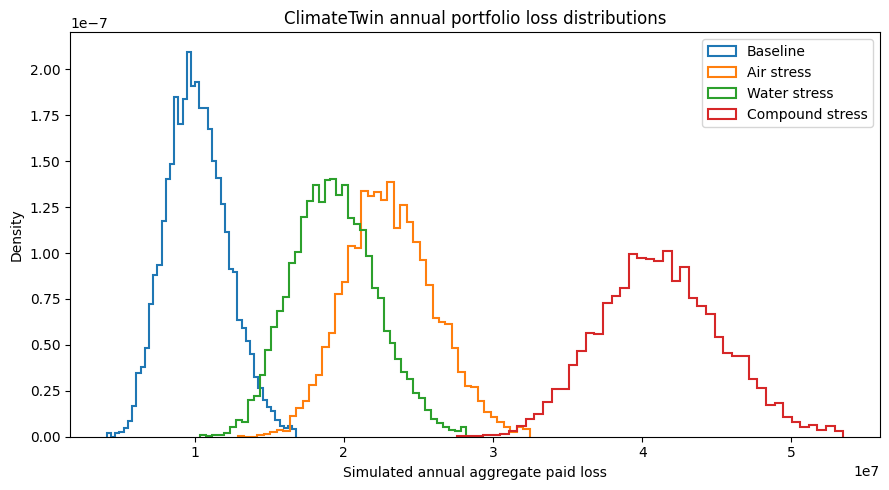

In [10]:
# Tail-risk comparison
plt.figure(figsize=(9,5))
for scenario in SCENARIOS:
    losses = scenario_results[scenario]["sims"]
    # Plot only up to the 99.7th percentile for readable classroom comparison.
    cap = np.quantile(losses, 0.997)
    clipped = losses[losses <= cap]
    plt.hist(clipped, bins=45, density=True, histtype="step", linewidth=1.5, label=scenario)

plt.xlabel("Simulated annual aggregate paid loss")
plt.ylabel("Density")
plt.title("ClimateTwin annual portfolio loss distributions")
plt.legend()
plt.tight_layout()
plt.show()


**Instructor checkpoint.** The compound scenario should be discussed through both expected loss and tail risk. Students should not conclude that the scenario with the largest environmental deterioration is automatically the largest insurance problem; exposure mix, financial terms, fitted frequency/severity and mitigation all matter.

## Stage 6 — Budget-constrained mitigation under compound stress

In [11]:
# Build individual upgrade candidates from the current 2026 location portfolio.
compound_base = apply_scenario(portfolio_2026, "Compound stress")
compound_pred = predict_portfolio(compound_base)

action_specs = {
    "Air filtration": ("air_filtration", "air_filtration_upgrade_cost"),
    "Water treatment": ("water_treatment", "water_treatment_upgrade_cost"),
    "BCP": ("business_continuity_plan", "bcp_upgrade_cost"),
}

candidate_rows = []
for idx, row in compound_base.iterrows():
    base_expected = compound_pred.loc[idx, "expected_loss"]

    for action, (flag_col, cost_col) in action_specs.items():
        if int(row[flag_col]) == 0 and float(row[cost_col]) > 0:
            changed = compound_base.loc[[idx]].copy()
            changed[flag_col] = 1
            changed = add_model_features(changed)
            changed_pred = predict_portfolio(changed)
            new_expected = float(changed_pred["expected_loss"].iloc[0])

            candidate_rows.append({
                "row_index": idx,
                "location_id": row["location_id"],
                "action": action,
                "flag_col": flag_col,
                "cost": float(row[cost_col]),
                "base_expected_loss": float(base_expected),
                "new_expected_loss": new_expected,
                "expected_loss_reduction": max(float(base_expected - new_expected), 0.0),
                "compound_flag": int(row["air_stress_flag"] * row["water_stress_flag"]),
            })

actions = pd.DataFrame(candidate_rows)
actions["bcr_proxy"] = actions["expected_loss_reduction"] / actions["cost"]
actions["tail_proxy"] = (
    actions["expected_loss_reduction"]
    * (1.0 + 0.75 * actions["compound_flag"])
    * np.sqrt(actions["base_expected_loss"].clip(lower=1))
    / actions["cost"]
)

display(actions.sort_values("bcr_proxy", ascending=False).head(10))
print("Candidate upgrades:", len(actions))


,row_index,location_id,action,flag_col,cost,base_expected_loss,new_expected_loss,expected_loss_reduction,compound_flag,bcr_proxy,tail_proxy
59,31,LOC032,BCP,business_continuity_plan,"60,000.000","928,034.821","479,210.843","448,823.978",1,7.480,"12,610.868"
317,183,LOC184,BCP,business_continuity_plan,"44,000.000","576,201.883","297,534.299","278,667.584",1,6.333,"8,413.160"
69,35,LOC036,BCP,business_continuity_plan,"50,000.000","616,815.440","318,505.988","298,309.453",1,5.966,"8,199.978"
199,109,LOC110,BCP,business_continuity_plan,"59,000.000","627,370.876","323,956.515","303,414.361",1,5.143,"7,128.273"
2,0,LOC001,BCP,business_continuity_plan,"60,000.000","637,350.832","329,109.881","308,240.951",1,5.137,"7,177.388"
412,242,LOC243,BCP,business_continuity_plan,"48,000.000","501,009.116","258,706.888","242,302.227",1,5.048,"6,252.836"
164,89,LOC090,BCP,business_continuity_plan,"53,000.000","543,968.223","280,889.752","263,078.471",1,4.964,"6,406.698"
136,71,LOC072,BCP,business_continuity_plan,"51,000.000","508,485.110","262,567.280","245,917.830",1,4.822,"6,017.236"
57,31,LOC032,Air filtration,air_filtration,"112,000.000","928,034.821","410,417.959","517,616.862",1,4.622,"7,791.312"
279,162,LOC163,BCP,business_continuity_plan,"73,000.000","694,916.156","358,834.981","336,081.175",1,4.604,"6,716.230"


Candidate upgrades: 427


In [12]:
def select_actions(actions_df, ranking_col, budget=RESILIENCE_BUDGET, action_filter=None):
    a = actions_df.copy()
    if action_filter is not None:
        a = a[a["action"].isin(action_filter)].copy()

    a = a.sort_values(ranking_col, ascending=False)
    selected = []
    spend = 0.0

    for _, r in a.iterrows():
        if spend + r["cost"] <= budget:
            selected.append(r)
            spend += r["cost"]

    return pd.DataFrame(selected), spend

def apply_actions_to_portfolio(base_portfolio, selected_actions):
    x = base_portfolio.copy()
    for _, a in selected_actions.iterrows():
        x.loc[int(a["row_index"]), a["flag_col"]] = 1
    return add_model_features(x)

candidate_strategies = {}

selected, spend = select_actions(actions, "bcr_proxy", action_filter=["Air filtration"])
candidate_strategies["Air-focused"] = (selected, spend)

selected, spend = select_actions(actions, "bcr_proxy", action_filter=["Water treatment"])
candidate_strategies["Water-focused"] = (selected, spend)

selected, spend = select_actions(actions, "bcr_proxy", action_filter=["BCP"])
candidate_strategies["BCP-focused"] = (selected, spend)

selected, spend = select_actions(actions, "bcr_proxy")
candidate_strategies["Balanced BCR-ranked"] = (selected, spend)

selected, spend = select_actions(actions, "tail_proxy")
candidate_strategies["Tail-focused"] = (selected, spend)

compound_baseline_metrics = scenario_results["Compound stress"]["metrics"]
compound_baseline_sims = scenario_results["Compound stress"]["sims"]

mitigation_rows = []
mitigation_details = {}

for i, (name, (selected, spend)) in enumerate(candidate_strategies.items()):
    mitigated = apply_actions_to_portfolio(compound_base, selected)
    pred = predict_portfolio(mitigated)
    sims = simulate_aggregate_loss(pred, n_sims=6000, seed=SEED + 100 + i)
    var99, tvar99 = var_tvar(sims)

    exp_loss = pred["expected_loss"].sum()
    indicated = pred["indicated_premium"].sum()
    current = pred["current_premium"].sum()
    exp_reduction = compound_baseline_metrics["Expected annual loss"] - exp_loss

    mitigation_rows.append({
        "Strategy": name,
        "Actions selected": len(selected),
        "Cost": spend,
        "Expected annual loss": exp_loss,
        "Expected-loss reduction": exp_reduction,
        "Benefit-cost ratio": exp_reduction / spend if spend > 0 else np.nan,
        "VaR99": var99,
        "TVaR99": tvar99,
        "TVaR reduction": compound_baseline_metrics["TVaR99"] - tvar99,
        "Post-mitigation adequacy": current / indicated,
    })
    mitigation_details[name] = {"selected": selected, "pred": pred, "sims": sims}

mitigation_table = pd.DataFrame(mitigation_rows).set_index("Strategy")
display(mitigation_table.sort_values("TVaR99"))

best_strategy = mitigation_table["TVaR99"].idxmin()
print("Selected strategy by minimum TVaR99:", best_strategy)
print("Budget used:", f'{mitigation_table.loc[best_strategy, "Cost"]:,.0f}')


,Actions selected,Cost,Expected annual loss,Expected-loss reduction,Benefit-cost ratio,VaR99,TVaR99,TVaR reduction,Post-mitigation adequacy
Strategy,,,,,,,,,
Balanced BCR-ranked,100,"7,995,000.000","25,876,548.648","15,361,062.889",1.921,"32,345,579.488","33,384,167.215","20,120,109.276",0.370
Tail-focused,95,"7,982,000.000","26,311,525.219","14,926,086.319",1.870,"32,815,192.863","33,889,146.646","19,615,129.845",0.364
Air-focused,82,"7,976,000.000","26,914,790.971","14,322,820.566",1.796,"33,659,454.934","34,605,891.327","18,898,385.164",0.355
BCP-focused,137,"7,078,000.000","28,280,888.371","12,956,723.167",1.831,"35,939,728.238","37,079,930.313","16,424,346.178",0.338
Water-focused,63,"7,989,000.000","30,877,230.964","10,360,380.573",1.297,"38,842,397.588","40,029,715.048","13,474,561.443",0.310


Selected strategy by minimum TVaR99: Balanced BCR-ranked
Budget used: 7,995,000


In [13]:
# Show composition of the selected mitigation portfolio.
best_actions = mitigation_details[best_strategy]["selected"]
action_mix = best_actions.groupby("action").agg(
    actions=("location_id","count"),
    cost=("cost","sum"),
    expected_loss_reduction_proxy=("expected_loss_reduction","sum")
)
display(action_mix)

# Compare compound stress before and after mitigation.
before = scenario_results["Compound stress"]["metrics"]
after_row = mitigation_table.loc[best_strategy]

comparison = pd.DataFrame({
    "Before mitigation": {
        "Expected annual loss": before["Expected annual loss"],
        "VaR99": before["VaR99"],
        "TVaR99": before["TVaR99"],
        "Adequacy ratio": before["Adequacy ratio"],
    },
    "After mitigation": {
        "Expected annual loss": after_row["Expected annual loss"],
        "VaR99": after_row["VaR99"],
        "TVaR99": after_row["TVaR99"],
        "Adequacy ratio": after_row["Post-mitigation adequacy"],
    }
})
display(comparison)


,actions,cost,expected_loss_reduction_proxy
action,,,
Air filtration,33,"3,262,000.000","8,510,136.586"
BCP,52,"2,778,000.000","9,011,800.385"
Water treatment,15,"1,955,000.000","4,216,241.510"


,Before mitigation,After mitigation
Expected annual loss,"41,237,611.538","25,876,548.648"
VaR99,"51,728,461.848","32,345,579.488"
TVaR99,"53,504,276.491","33,384,167.215"
Adequacy ratio,0.232,0.370


## Final Climate Risk Committee recommendation

The exact wording should reflect the executed results above. A strong answer should make the following points:

1. **Coverage logic first.** Environmental stress is a risk signal, not a claim. The endorsement requires a qualifying insured trigger before claim frequency/severity become relevant.
2. **Baseline pricing.** Compare modeled 2026 expected loss and indicated premium with current premium and identify the least adequate segments.
3. **Stress result.** Identify the scenario with the most material deterioration in expected loss and, separately, in TVaR. If these differ, explain why.
4. **Compound risk.** Do not assume `Air + Water = Compound`. The fitted interaction and changed environmental state can alter both frequency and tail behavior.
5. **Mitigation.** Select the feasible candidate strategy with the lowest TVaR99 under the 8,000,000 budget. Report BCR as supporting information rather than the sole objective.
6. **Reprice after intervention.** Recalculate indicated premium after mitigation; risk reduction does not automatically imply that current premium becomes adequate.
7. **Management action.** A defensible recommendation will normally combine **Reprice + Mitigate + Monitor**, with selective term/capacity changes for the most inadequate segments rather than indiscriminate withdrawal.


## Limitations to communicate

At minimum, management should be told that:

- the data are synthetic and calibrated for instruction, not real-world pricing;
- the frequency and severity GLMs are simplified and not intended as causal models;
- 2026 is treated as the current annual portfolio snapshot while all years are used for fitting;
- Monte Carlo tail estimates have simulation error;
- scenario transformations are deterministic teaching stresses, not climate forecasts;
- the core case does not explicitly model spatial dependence, copulas, reinsurance, credibility, or parameter uncertainty; and
- mitigation effects are inferred from the synthetic teaching data and should not be interpreted as engineering effectiveness estimates.

These limitations are part of professional actuarial communication, not an afterthought.
